In [37]:
import numpy as np
import matplotlib.pyplot as plt

import SIR_models

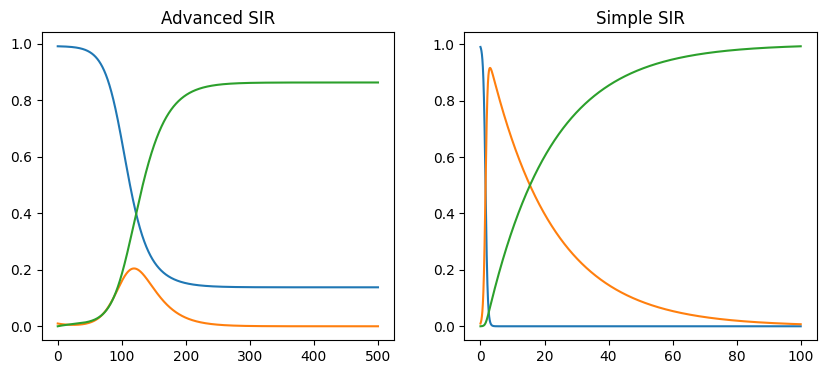

In [5]:
b = 3
g = 0.05

kmax = 100
S = np.zeros(kmax)
I = np.zeros(kmax)
R = np.zeros(kmax)

timespace = np.linspace(0, 500, 10000)


#poisson
lS = 50
lI = 80
sampleS = np.random.poisson(lS, 100000)
sampleI = np.random.poisson(lI, 1000)
for i in range(kmax):
    S[i] = sum(sampleS == i)
    I[i] = sum(sampleI == i)

n = S.sum() + I.sum()

S /= n
I /= n

Slist, Ilist, Rlist = SIR_models.new_model(timespace, S, I, R, b, g)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(timespace, Slist.sum(1), timespace, Ilist.sum(1),timespace, Rlist.sum(1), )
ax1.set_title("Advanced SIR")

S = S.sum()
I = I.sum()
R = R.sum()

timespace = np.linspace(0, 100, 10000)
Slist, Ilist, Rlist = SIR_models.old_model(timespace, S, I, R, b, g)

ax2.plot(timespace, Slist, timespace, Ilist, timespace, Rlist)
ax2.set_title("Simple SIR")
plt.show()


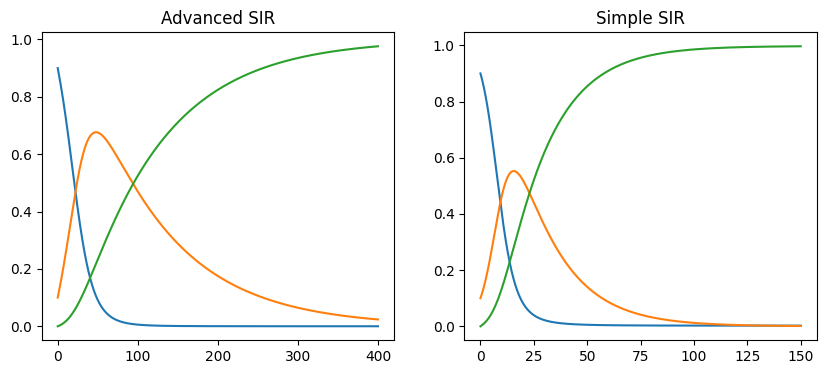

In [177]:
b = 0.5
g = 0.01

kmax = 100
S = np.zeros(kmax)
I = np.zeros(kmax)
R = np.zeros(kmax)

timespace = np.linspace(0, 400, 10000)



al = 2.5

k = np.arange(0, kmax)
k[0] = 1

k = 1/(k**al)

k[0] = 0

k = k/k.sum()

S = 0.9*k
I = 0.1*k

Slist, Ilist, Rlist = new_model(timespace, S, I, R, b, g)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(timespace, Slist.sum(1), timespace, Ilist.sum(1),timespace, Rlist.sum(1), )
ax1.set_title("Advanced SIR")

S = S.sum()
I = I.sum()
R = R.sum()

timespace = np.linspace(0, 150, 10000)
Slist, Ilist, Rlist = old_model(timespace, S, I, R)

ax2.plot(timespace, Slist, timespace, Ilist, timespace, Rlist, b, g)
ax2.set_title("Simple SIR")
plt.show()


In [ ]:
al = 2.5
k = np.arange(1, kmax)


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

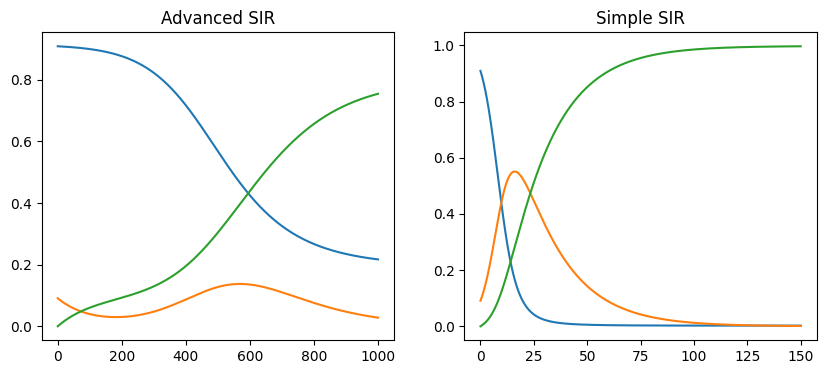

In [ ]:
b = 0.5
g = 0.01

kmax = 100
S = np.zeros(kmax)
I = np.zeros(kmax)
R = np.zeros(kmax)

timespace = np.linspace(0, 1000, 10000)


#poisson
lS = 50
lI = 5
sampleS = np.random.poisson(lS, 10000)
sampleI = np.random.poisson(lI, 1000)
for i in range(kmax):
    S[i] = sum(sampleS == i)
    I[i] = sum(sampleI == i)

n = S.sum() + I.sum()

S /= n
I /= n


Slist, Ilist, Rlist = new_model(timespace, S, I, R, b, g)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(timespace, Slist.sum(1), timespace, Ilist.sum(1),timespace, Rlist.sum(1), )
ax1.set_title("Advanced SIR")

S = S.sum()
I = I.sum()
R = R.sum()

timespace = np.linspace(0, 150, 10000)
Slist, Ilist, Rlist = old_model(timespace, S, I, R)

ax2.plot(timespace, Slist, timespace, Ilist, timespace, Rlist, b, g)
ax2.set_title("Simple SIR")
plt.show()


In [44]:
k
Slist[0]

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.99])

In [36]:
k

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [25]:
print(dt)

0.001000100010001


In [83]:
import random
import math
import networkx as nx


def run_epi(graph, b, g, cs0):
    reds = set()
    blues = set(graph.nodes)
    blue_ns = list()
    times = list()
    times.append(0)
    greens = set()
    reds.add(cs0)
    blues.remove(cs0)
    st = [len(blues)]
    it = [1]
    rt = [0]
    #initialization of epidemic
    reds = set()
    blues = set(graph.nodes)
    blue_ns = list()
    times = list()
    times.append(0)
    greens = set()

    reds.add(cs0)
    blues.remove(cs0)
    st = [len(blues)]
    it = [1]
    rt = [0]         

    while True:
        blue_ns = []
        for red in reds:
            for neighbor in graph.neighbors(red):
                if neighbor in blues:
                    blue_ns.append(neighbor)
        ne = len(blue_ns)
        i = len(reds)
        pi = b * ne / (b * ne + i * g)
        pr = g * i / (b * ne + i * g)
        dtime = 1 / (b * ne + i * g) * math.log(1./random.random())
        chance = random.random()

        if chance <= pi:
            new_red = random.choice(blue_ns)
            reds.add(new_red)
            blues.remove(new_red)
            blue_ns.remove(new_red)
        else:
            new_green = random.choice(list(reds))
            reds.remove(new_green)
            greens.add(new_green)
        times.append(times[-1] + dtime)
        st.append(len(blues))
        it.append(len(reds))
        rt.append(len(greens))
        if len(reds) == 0:
            break

    return [np.array(times), np.array(st), np.array(it), np.array(rt)]

In [223]:
def run_aver(graph, b, g, cs0, num=100, divider=1000):
    defres = []
    timelist = []
    for i in range(num):
        defres.append(run_epi(graph, b, g, cs0))
        timelist.append(defres[-1][0][-1])
    
    timelist = np.array(timelist)
    sorttime = np.argsort(timelist)   
    maxtime = max(timelist)            
            
    abstimes = np.linspace(0, maxtime, divider)

    news = []
    newi = []
    newr = []

    for j in range(num):
        if j in sorttime[(num // 4):]:
            news.append(np.interp(abstimes, defres[j][0], defres[j][1], right = defres[j][1][-1]))
            newi.append(np.interp(abstimes, defres[j][0], defres[j][2], right = defres[j][2][-1]))
            newr.append(np.interp(abstimes, defres[j][0], defres[j][3], right = defres[j][3][-1]))

    avers = np.mean(news, axis = 0)
    averi = np.mean(newi, axis = 0)
    averr = np.mean(newr, axis = 0)
    
    j = divider-1
    while j > 1 and averi[j] < 0.5:
        j -= 1
    
    return(abstimes[:j+1], avers[:j+1], averi[:j+1], averr[:j+1])

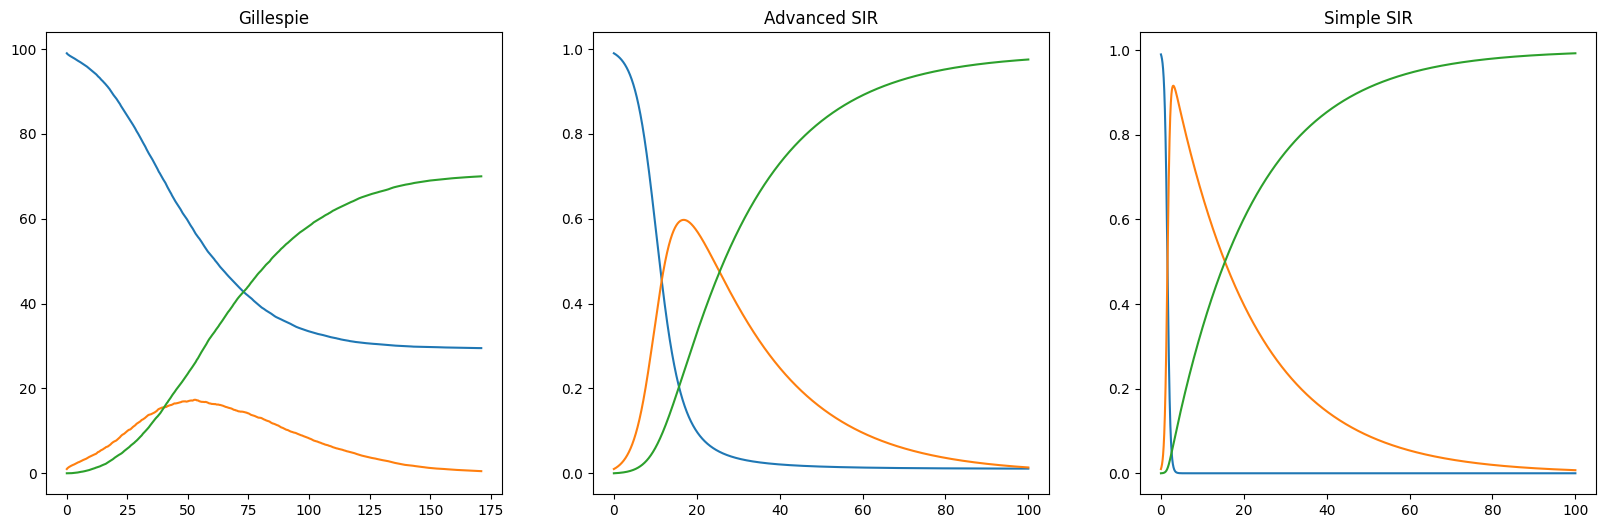

In [227]:
ndots = 100

bo = 0.03
go = 0.05

net = nx.complete_graph(ndots)
net = nx.erdos_renyi_graph(n=ndots, p=0.05)
cs0 = list(net.nodes)[0]

t, st, it, rt = run_aver(net, bo, go, cs0, num=200)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.plot(t, st, t, it, t, rt)
ax1.set_title("Gillespie")

b = 3
g = 0.05

S = np.zeros(ndots)
I = np.zeros(ndots)
R = np.zeros(ndots)

for node in net.nodes:
    S[nx.degree(net, node)] += 1

S[nx.degree(net, cs0)] -= 1
I[nx.degree(net, cs0)] += 1

n = S.sum() + I.sum()
S /= n
I /= n

Slist, Ilist, Rlist = SIR_models.new_model(timespace, S, I, R, b, g)

ax2.plot(timespace, Slist.sum(1), timespace, Ilist.sum(1),timespace, Rlist.sum(1), )
ax2.set_title("Advanced SIR")

S = S.sum()
I = I.sum()
R = R.sum()

timespace = np.linspace(0, 100, 10000)
Slist, Ilist, Rlist = SIR_models.old_model(timespace, S, I, R, b, g)

ax3.plot(timespace, Slist, timespace, Ilist, timespace, Rlist)
ax3.set_title("Simple SIR")
plt.show()


/Users/anton/docs/smtb/SIR_models.py:10: RuntimeWarning: overflow encountered in scalar multiply
  Sd = -b * I * S
/Users/anton/docs/smtb/SIR_models.py:11: RuntimeWarning: overflow encountered in scalar multiply
  Id = b * I * S - g * I


ValueError: array must not contain infs or NaNs

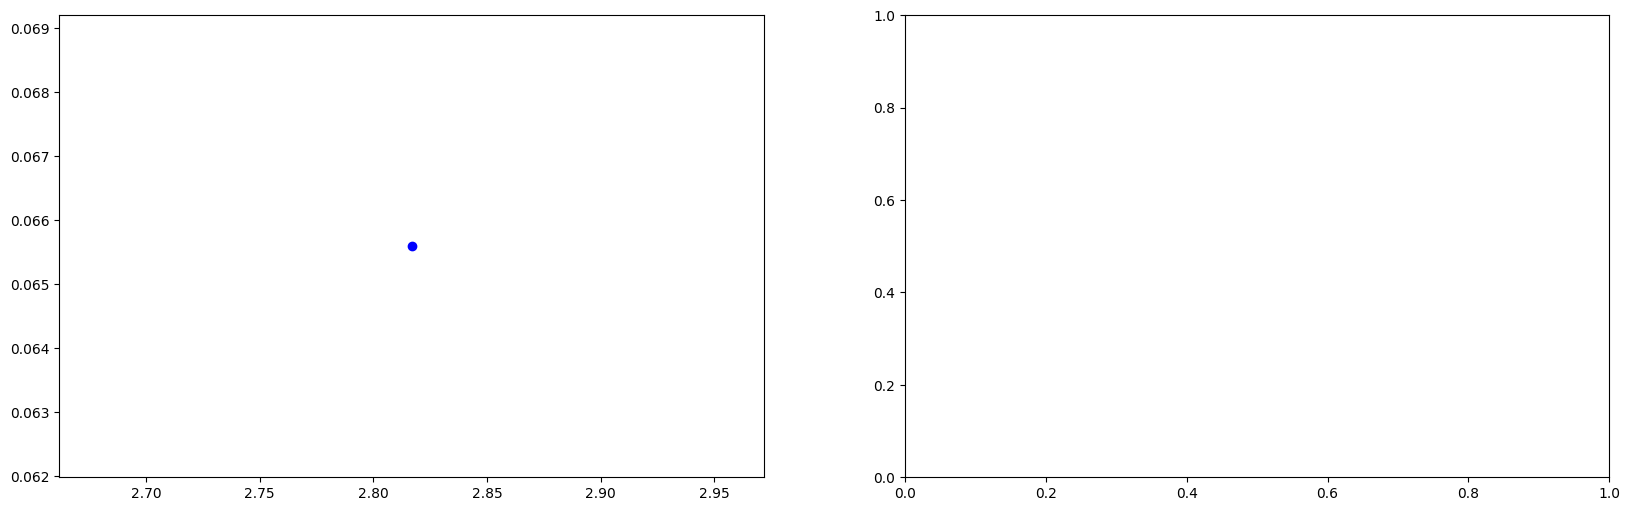

In [270]:
from scipy.optimize import minimize
from scipy.spatial import distance

ndots = 100

bo = 0.03
go = 0.05

#net = nx.complete_graph(ndots)
#net = nx.erdos_renyi_graph(n=ndots, p=0.5)
#net = nx.barabasi_albert_graph(n=ndots, m=30)
net = nx.grid_2d_graph(10, 10)

cs0 = list(net.nodes)[0]

ndots = len(net.nodes)

S = (ndots - 1) / ndots
I = 1 / ndots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

errors = []
for i in range(100):
    t, st, it, rt = run_epi(net, bo, go, cs0)
    it = it / ndots
    if len(t) < 5:
        continue

    def min_func(x):
        Slist, Ilist, Rlist = SIR_models.old_model(t, S, I, R, x[0], x[1])
        dist = distance.euclidean(it, Ilist)
        return dist

    result = minimize(min_func, [bo * ndots, go], bounds=[(0.00001, None),(0.00001, None)], method='nelder-mead')
    errors.append(result.fun)
    
    ax1.scatter(result.x[0], result.x[1], color='blue')

ax1.scatter(bo * ndots, go, color='red', marker='x', s=200)
ax2.boxplot(errors)
plt.show()
    

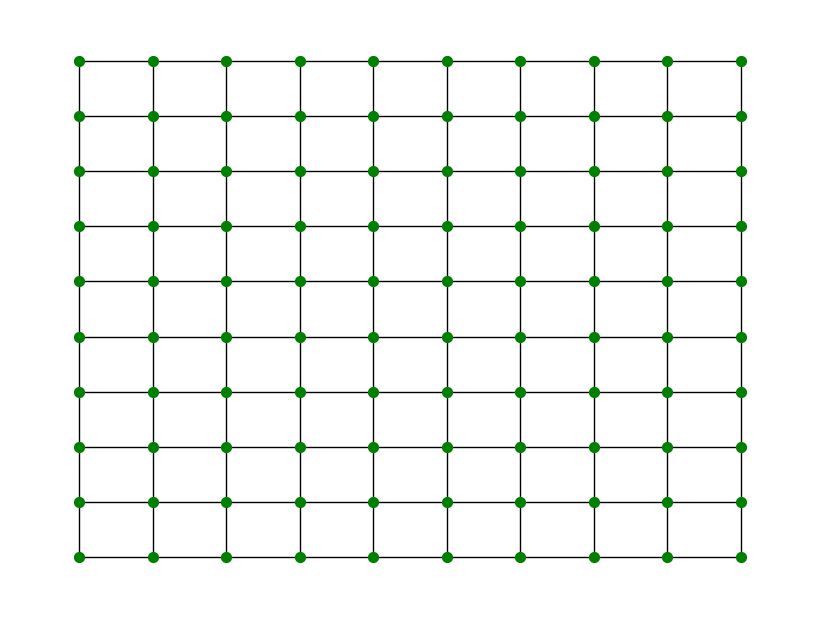

In [263]:
H = nx.grid_2d_graph(10, 10)
pos = dict((n, n) for n in H.nodes())
plt.figure(figsize=(8, 6))
nx.draw(H, pos, node_size=50, with_labels=False, node_color='green')
plt.show()

array([0.01      , 0.01029203, 0.01059249, ..., 0.00729322, 0.00728958,
       0.00728593], shape=(10000,))

In [199]:
min_func([10, 0.06])

np.float64(60.1044)